# Laboratorio 6 - ¿Puede una red neuronal aprender a sumar?
## Calculadora neuronal con seq2seq y atención

**Universidad del Valle · Deep Learning 2026 · Kevin Recinos**

**Modalidad:** individual  
**Trabajo en clase:** viernes 2 y lunes 5 de octubre  
**Entrega:** jueves 8 de octubre de 2026, 23:59  
**Archivo:** este notebook ejecutado (su calculadora se registra sola al final)  
**Valor:** este laboratorio cuenta como **dos laboratorios**: el notebook es el Laboratorio 6 (100 puntos) y
el torneo es el Laboratorio 7

Una red recibe el texto `"4821+3976"` y debe escribir `"8797"`, carácter por carácter. Nadie le explica
qué es sumar ni qué es "llevar uno": solo ve ejemplos. Usted va a construir la pieza que le permite  
**mirar la parte correcta del problema** en cada paso -la atención de Bahdanau- y luego va a comprobar,
con un mapa de atención, si la red descubrió la suma por columnas que usted aprendió en la escuela.

El viernes 9 de octubre, en clase, su calculadora participa en el **Torneo de calculadoras neuronales**:
el profesor dice una clave, su notebook resuelve los problemas secretos y registra sus respuestas solo.  
**Su nota del Laboratorio 7** es su puntaje en el torneo dividido entre el mejor puntaje de la clase, por 100: **la mejor calculadora obtiene 100**, y nadie que envíe su calculadora baja de **60**. Vale 4 puntos de la nota final.

### Cómo se trabaja

| Bloque | Qué va a hacer | Tiempo | Puntos |
|:--|:--|:--:|--:|
| 0 | **Investigar.** Dos lecturas y tres preguntas | 30 min | 15 |
| 1 | **Ejecutar y observar.** El generador de problemas | 10 min | 5 |
| 2 | **Programar.** El módulo de atención aditiva | 25 min | 20 |
| 3 | **Programar.** Un paso del decoder con atención | 15 min | 15 |
| 4 | **Entrenar.** Calculadora con y sin atención | 15 min | 10 |
| 5 | **Analizar.** Exactitud por cifras y mapa de atención | 25 min | 15 |
| 6 | **Investigar con evidencia.** Su calculadora para el torneo | 40 min | 10 |
| 7 | **Romper su propia calculadora** y cerrar | 20 min | 10 |

Las celdas con `assert` son su verificación: si imprimen `OK`, el bloque está bien. Si fallan, corrija
antes de avanzar. **Solo programa en los Bloques 2 y 3**; el resto del código ya está escrito y usted lo
ejecuta, lo modifica a través de `CONFIG` y lo interpreta.

### Reglas

- Use PyTorch, matplotlib y la biblioteca estándar de Python. No use NumPy.
- No use `nn.MultiheadAttention` ni otra implementación de atención: la del Bloque 2 es suya.
- No modifique las celdas de verificación.
- La calculadora jamás puede calcular la respuesta con Python (`eval`, `int(a) + int(b)`, etc.): la
  respuesta sale del modelo, carácter por carácter.
- Respuestas escritas con sus propias palabras. Una IA no se considera fuente académica.
- Entregue el notebook ejecutado de arriba abajo, con todas las salidas visibles.

In [33]:
# Escriba sus datos. El carné identifica su calculadora en el torneo.
NOMBRE = "Anggie Quezada"
CARNE = "23643"

assert CARNE != "00000" and NOMBRE != "Escriba aquí su nombre", "Complete NOMBRE y CARNE."
print("OK -", NOMBRE, CARNE)

OK - Anggie Quezada 23643


In [34]:
import hashlib
import json
import random
import time
from pathlib import Path
from urllib.parse import parse_qs, urlencode, urlparse
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence

SEMILLA = 2026
DISPOSITIVO = torch.device("cpu")  # el modelo es pequeño: en CPU entrena en 1-3 minutos
CARPETA_MODELOS = Path("modelos_lab6")
CARPETA_MODELOS.mkdir(exist_ok=True)


FORMULARIO = "https://docs.google.com/forms/d/e/1FAIpQLScMnEK5G8RncUK09wLMJly1rNUmyMADWZ1Kk2KhuVKX8HEGew/viewform?usp=pp_url&entry.602518229=x"


def enviar_registro(datos):
    """Envía un registro JSON al formulario del curso. Si falla, muestra el texto para pegarlo a mano."""
    texto = json.dumps(datos, ensure_ascii=False)
    try:
        partes = urlparse(FORMULARIO)
        campo = next(k for k in parse_qs(partes.query) if k.startswith("entry."))
        destino = f"{partes.scheme}://{partes.netloc}{partes.path.replace('viewform', 'formResponse')}"
        cuerpo = urlencode({campo: texto}).encode()
        with urlopen(Request(destino, data=cuerpo), timeout=20) as respuesta:
            assert respuesta.status == 200
        print("OK - registro enviado al formulario del curso")
        return True
    except Exception as error:
        print(f"No se pudo enviar el registro ({type(error).__name__}).")
        print("Abra el formulario del curso y pegue este texto completo en la única pregunta:\n")
        print(texto)
        return False


print("PyTorch", torch.__version__)

PyTorch 2.14.1


---
## Bloque 0 - Investigación guiada (15 puntos)

Antes de escribir código, lea estas dos secciones. Son cortas.

- **Bahdanau, Cho y Bengio (2014).** *Neural Machine Translation by Jointly Learning to Align and
  Translate.* Sección 3.1 y figura 3. <https://arxiv.org/abs/1409.0473>
- **Sutskever, Vinyals y Le (2014).** *Sequence to Sequence Learning with Neural Networks.* Sección 3.3,
  *Reversing the Source Sentences*. <https://arxiv.org/abs/1409.3215>

Responda en 3 a 6 líneas cada una, con lenguaje propio, y cite la sección utilizada.

1. Según Bahdanau, ¿qué problema aparece cuando el encoder debe comprimir toda la entrada en **un solo
   vector de tamaño fijo**? ¿Cómo lo resuelve el vector de contexto $c_i$, que cambia en cada paso de
   salida?
2. En el artículo, el puntaje $e_{ij} = a(s_{i-1}, h_j)$ compara el estado del decoder con cada estado del
   encoder. Explique qué serían $s_{i-1}$ y $h_j$ cuando la red está escribiendo el **tercer** dígito de la
   respuesta de `4821+3976`. ¿Qué pieza del Transformer del Lab 5 cumple el papel de $s_{i-1}$ y cuál el de
   $h_j$?
3. ¿Por qué invertir la oración de entrada mejoró los resultados de Sutskever? Ahora piense en cómo suma
   usted a mano: ¿empieza por la izquierda o por la derecha? **Antes de entrenar nada**, prediga: ¿ayudará
   a la calculadora invertir la entrada, la salida o ambas? Justifique su predicción.

### Respuestas

**1.** Un solo vector puede perder detalles de la entrada. Con $c_i$, el decoder vuelve a mirar las partes que necesita para cada dígito.  
**Fuente:** Bahdanau, Cho y Bengio (2014), sección 3.1.

**2.** $4821+3976=8797$. Al escribir el tercer dígito (9), $s_{i-1}$ resume lo que el decoder ya escribió (87); cada $h_j$ representa una posición de la entrada. En un Transformer con encoder y decoder, corresponden a la consulta del decoder y a las representaciones del encoder. Si el Lab 5 usa solo decoder, la equivalencia es aproximada.  
**Fuente:** Bahdanau, Cho y Bengio (2014), sección 3.1.

**3.** Sutskever invirtió la entrada porque acercó información relacionada y facilitó aprender. Para la suma, predigo que ayudaría invertir cada número y la respuesta: así la red empieza por las unidades, como hacemos a mano, y puede seguir los acarreos.  
**Fuente:** Sutskever, Vinyals y Le (2014), sección 3.3.


---
## Bloque 1 - El generador de problemas (5 puntos)

No hay archivo de datos: cada problema se genera al azar. Los dos números tienen entre 1 y 4 cifras, la
operación es `+` o `-`, y en las restas el resultado nunca es negativo. Cada carácter es un *token*: el
vocabulario completo tiene 15 símbolos.

Ejecute la celda y observe los ejemplos.

      42-1 -> 41     tokens: [7, 5, 14, 4]
 7219+4439 -> 11658  tokens: [10, 5, 4, 12, 13, 7, 7, 6, 12]
    7386+6 -> 7392   tokens: [10, 6, 11, 9, 13, 9]
  4748+705 -> 5453   tokens: [7, 10, 7, 11, 13, 10, 3, 8]
     122+0 -> 122    tokens: [4, 5, 5, 13, 3]
   7915+13 -> 7928   tokens: [10, 12, 4, 8, 13, 4, 6]
 4818+6663 -> 11481  tokens: [7, 11, 4, 11, 13, 9, 9, 9, 6]
   1352-47 -> 1305   tokens: [4, 6, 8, 5, 14, 7, 10]


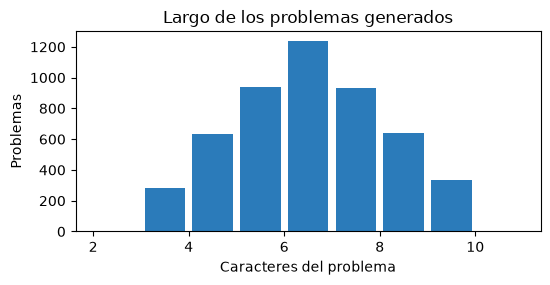

OK - generador y vocabulario listos


In [35]:
ESPECIALES = ["<PAD>", "<SOS>", "<EOS>"]
SIMBOLOS = list("0123456789+-")
TOKENS = ESPECIALES + SIMBOLOS
TOKEN_A_ID = {token: i for i, token in enumerate(TOKENS)}
PAD, SOS, EOS = 0, 1, 2
MAX_CIFRAS = 4  # regla del torneo: nadie entrena con números de más de 4 cifras


def generar_problema(rng, max_cifras=MAX_CIFRAS, min_cifras=1):
    """Devuelve (problema, respuesta) como texto, por ejemplo ("4821+3976", "8797")."""
    cifras_a = rng.randint(min_cifras, max_cifras)
    cifras_b = rng.randint(1, max_cifras)
    a = rng.randint(0 if cifras_a == 1 else 10 ** (cifras_a - 1), 10 ** cifras_a - 1)
    b = rng.randint(0 if cifras_b == 1 else 10 ** (cifras_b - 1), 10 ** cifras_b - 1)
    operacion = rng.choice("+-")
    if operacion == "-" and a < b:
        a, b = b, a
    respuesta = a + b if operacion == "+" else a - b
    return f"{a}{operacion}{b}", str(respuesta)


def generar_datos(n, semilla, max_cifras=MAX_CIFRAS):
    rng = random.Random(semilla)
    return [generar_problema(rng, max_cifras) for _ in range(n)]


def codificar(texto, inicio_fin):
    ids = [TOKEN_A_ID[c] for c in texto]
    return [SOS] + ids + [EOS] if inicio_fin else ids


ejemplos = generar_datos(8, semilla=1)
for problema, respuesta in ejemplos:
    print(f"{problema:>10} -> {respuesta:<6} tokens: {codificar(problema, False)}")

validacion = generar_datos(2000, semilla=SEMILLA + 1)
largos = [len(p) for p, _ in generar_datos(5000, semilla=3)]
plt.figure(figsize=(6, 2.6))
plt.hist(largos, bins=range(2, 12), rwidth=0.85, color="#2b7bba")
plt.xlabel("Caracteres del problema")
plt.ylabel("Problemas")
plt.title("Largo de los problemas generados")
plt.show()

assert len(TOKENS) == 15 and codificar("12+3", True) == [SOS, 4, 5, 13, 6, EOS]
print("OK - generador y vocabulario listos")

**Pregunta 1.1.** ¿Cuántos problemas distintos con dos números de **exactamente 4 cifras** existen
(considere `+` y `-`)? El modelo entrena con 40,000 ejemplos en total. ¿Qué implica esa comparación sobre
si el modelo puede memorizar las respuestas?

Hay 9,000 números de exactamente 4 cifras (del 1000 al 9999).
- **Sumas:** cualquier par sirve, así que hay $9000 \times 9000 = 81{,}000{,}000$ problemas.
- **Restas:** como el resultado no puede ser negativo, solo cuentan los pares con $a \ge b$: $\frac{9000 \times 9001}{2} = 40{,}504{,}500$ problemas.
- **Total:** $\approx 121{,}504{,}500$ problemas distintos.

El modelo ve 40,000 ejemplos, y de esos solo una parte tiene ambos números de 4 cifras: es menos del **0.03 %** de los casos posibles. Memorizar es imposible, como estudiar para un examen viendo una pregunta de cada 3,000. Si el modelo acierta problemas de 4 cifras que nunca vio, es porque aprendió una **regla** (sumar columna por columna con acarreo) y no una tabla de respuestas.


---
## Bloque 2 - La atención aditiva de Bahdanau (20 puntos)

El encoder lee el problema y deja un vector $h_j$ por cada carácter. Cada vez que el decoder va a escribir
un dígito, tiene un estado $s$ que resume lo que lleva escrito. La atención responde: **¿qué caracteres del
problema necesito mirar ahora?**

Se hace en tres pasos pequeños:

**Paso 1 - puntaje.** Una pequeña red compara el estado del decoder con cada carácter:

$$e_j = v^\top \tanh\left(W_q\, s + W_k\, h_j\right)$$

**Paso 2 - pesos.** Los puntajes se convierten en porcentajes que suman 1. Los `<PAD>` reciben puntaje
$-\infty$ para que su peso sea exactamente 0:

$$\alpha_j = \frac{e^{e_j}}{\sum_k e^{e_k}}$$

**Paso 3 - contexto.** El contexto es el promedio de los $h_j$, ponderado por los pesos:

$$c = \sum_j \alpha_j\, h_j$$

Las capas $W_q$, $W_k$ y $v$ ya están creadas. Usted escribe el `forward`. Formas de los tensores
(B = tamaño del lote, T = caracteres del problema):

| Tensor | Forma | Significado |
|:--|:--|:--|
| `estado_dec` | (B, dim_dec) | estado $s$ del decoder |
| `salidas_enc` | (B, T, dim_enc) | un $h_j$ por carácter |
| `mascara_pad` | (B, T) | `True` donde hay `<PAD>` |
| `contexto` (salida) | (B, dim_enc) | vector $c$ |
| `pesos` (salida) | (B, T) | los $\alpha_j$, suman 1 por fila |

In [36]:
class AtencionAditiva(nn.Module):
    def __init__(self, dim_dec, dim_enc, dim_att):
        super().__init__()
        self.W_q = nn.Linear(dim_dec, dim_att, bias=False)
        self.W_k = nn.Linear(dim_enc, dim_att, bias=False)
        self.v = nn.Linear(dim_att, 1, bias=False)

    def forward(self, estado_dec, salidas_enc, mascara_pad):
        # TODO paso 1: puntajes (B, T). Agregue la dimensión T a W_q(s) para sumarlo con W_k(h).
        # TODO paso 2: ponga -inf donde mascara_pad es True y aplique softmax sobre T.
        # TODO paso 3: contexto (B, dim_enc) como suma ponderada de salidas_enc.
        # Ejemplos de funciones que puede utilizar:
        # Tensor.unsqueeze(1), torch.tanh(...), Tensor.squeeze(-1)
        # Tensor.masked_fill(mascara, float("-inf")), torch.softmax(..., dim=-1)
        # torch.bmm(pesos.unsqueeze(1), salidas_enc)
        # Paso 1: cada carácter recibe un puntaje de "qué tan útil es mirarlo ahora".
        consulta = self.W_q(estado_dec).unsqueeze(1)                      # (B, 1, dim_att)
        claves = self.W_k(salidas_enc)                                    # (B, T, dim_att)
        puntajes = self.v(torch.tanh(consulta + claves)).squeeze(-1)      # (B, T)
        # Paso 2: los <PAD> no cuentan; softmax convierte puntajes en porcentajes que suman 1.
        puntajes = puntajes.masked_fill(mascara_pad, float("-inf"))
        pesos = torch.softmax(puntajes, dim=-1)                           # (B, T)
        # Paso 3: el contexto es el promedio de los h_j, ponderado por los pesos.
        contexto = torch.bmm(pesos.unsqueeze(1), salidas_enc).squeeze(1)  # (B, dim_enc)
        return contexto, pesos

In [37]:
# Verificación con pesos fijos: todos deben obtener exactamente los mismos números.
torch.manual_seed(0)
att_prueba = AtencionAditiva(dim_dec=6, dim_enc=8, dim_att=5)
s_prueba = torch.randn(2, 6)
h_prueba = torch.randn(2, 4, 8)
mascara_prueba = torch.tensor([[False, False, False, False],
                               [False, False, True, True]])  # el 2.º problema es más corto

with torch.no_grad():
    contexto_b2, pesos_b2 = att_prueba(s_prueba, h_prueba, mascara_prueba)

assert contexto_b2 is not None and pesos_b2 is not None, "Complete el forward."
assert pesos_b2.shape == (2, 4) and contexto_b2.shape == (2, 8)
assert torch.allclose(pesos_b2.sum(-1), torch.ones(2)), "Los pesos deben sumar 1 por fila."
assert torch.all(pesos_b2[1, 2:] == 0), "Los <PAD> deben recibir peso exactamente 0."
print("pesos:\n", pesos_b2.round(decimals=4))
print("OK - atención aditiva correcta")

pesos:
 tensor([[0.3175, 0.1590, 0.2044, 0.3191],
        [0.5266, 0.4734, 0.0000, 0.0000]])
OK - atención aditiva correcta


---
## Bloque 3 - Un paso del decoder con atención (15 puntos)

El decoder escribe la respuesta un carácter a la vez. En cada paso:

1. Convierte el token anterior en un embedding (al inicio, el token anterior es `<SOS>`).
2. Le pregunta a la atención qué mirar, usando su estado **actual** (todavía no actualizado): obtiene
   `contexto` y `pesos`.
3. Actualiza su estado con la `GRUCell`, que recibe **[embedding, contexto]** concatenados en ese orden.
4. Calcula los logits del siguiente carácter con la capa `salida`, que recibe **[nuevo_estado, contexto]**
   concatenados en ese orden.

El encoder ya está escrito. Fíjese en `pack_padded_sequence`: le indica a la GRU dónde termina cada
problema para que nunca lea los `<PAD>`. Sin eso, el modelo aprende a depender del relleno y falla cuando
el lote no lo trae.

In [38]:
class Encoder(nn.Module):
    """GRU bidireccional: un vector por carácter y un resumen de todo el problema."""

    def __init__(self, n_tokens, dim_emb, dim_oculta):
        super().__init__()
        self.embedding = nn.Embedding(n_tokens, dim_emb, padding_idx=PAD)
        self.gru = nn.GRU(dim_emb, dim_oculta, batch_first=True, bidirectional=True)
        self.puente = nn.Linear(2 * dim_oculta, 2 * dim_oculta)

    def forward(self, src):
        largos = src.ne(PAD).sum(1).cpu()
        empaquetado = pack_padded_sequence(self.embedding(src), largos,
                                           batch_first=True, enforce_sorted=False)
        salidas, h_n = self.gru(empaquetado)
        salidas, _ = pad_packed_sequence(salidas, batch_first=True, total_length=src.size(1))
        resumen = torch.cat([h_n[0], h_n[1]], dim=-1)       # (B, 2*dim_oculta)
        estado_inicial = torch.tanh(self.puente(resumen))   # estado inicial del decoder
        return salidas, estado_inicial, resumen

In [39]:
class Decoder(nn.Module):
    def __init__(self, n_tokens, dim_emb, dim_dec, dim_enc, dim_att, usar_atencion=True):
        super().__init__()
        self.usar_atencion = usar_atencion
        self.embedding = nn.Embedding(n_tokens, dim_emb, padding_idx=PAD)
        self.atencion = AtencionAditiva(dim_dec, dim_enc, dim_att)
        self.gru = nn.GRUCell(dim_emb + dim_enc, dim_dec)
        self.salida = nn.Linear(dim_dec + dim_enc, n_tokens)

    def paso(self, token_previo, estado, salidas_enc, mascara_pad, resumen):
        """token_previo (B,), estado (B, dim_dec) -> logits (B, n_tokens), nuevo_estado, pesos."""
        if not self.usar_atencion:
            # Versión SIN atención (ya escrita): el contexto es siempre el mismo resumen fijo.
            contexto, pesos = resumen, None
            emb = self.embedding(token_previo)
            nuevo_estado = self.gru(torch.cat([emb, contexto], dim=-1), estado)
            return self.salida(torch.cat([nuevo_estado, contexto], dim=-1)), nuevo_estado, pesos

        # TODO 1: embedding del token previo.
        # TODO 2: contexto y pesos con self.atencion, usando el estado ACTUAL.
        # TODO 3: nuevo_estado con self.gru sobre [embedding, contexto].
        # TODO 4: logits con self.salida sobre [nuevo_estado, contexto].
        # Observe la versión sin atención de arriba: solo cambia de dónde sale el contexto.
        # Ejemplos de funciones que puede utilizar:
        # self.embedding(...), self.atencion(...), torch.cat([...], dim=-1)
        # self.gru(entrada, estado), self.salida(...)
        emb = self.embedding(token_previo)
        contexto, pesos = self.atencion(estado, salidas_enc, mascara_pad)
        nuevo_estado = self.gru(torch.cat([emb, contexto], dim=-1), estado)
        logits = self.salida(torch.cat([nuevo_estado, contexto], dim=-1))
        return logits, nuevo_estado, pesos

In [40]:
# Verificación con pesos fijos.
torch.manual_seed(1)
dec_prueba = Decoder(n_tokens=15, dim_emb=4, dim_dec=6, dim_enc=8, dim_att=5)
token_prueba = torch.tensor([SOS, 7])
with torch.no_grad():
    logits_b3, estado_b3, pesos_b3 = dec_prueba.paso(
        token_prueba, s_prueba, h_prueba, mascara_prueba, resumen=None
    )

assert logits_b3 is not None, "Complete el método paso."
assert logits_b3.shape == (2, 15) and estado_b3.shape == (2, 6) and pesos_b3.shape == (2, 4)
assert torch.all(pesos_b3[1, 2:] == 0)
print("logits del primer problema:", logits_b3[0].round(decimals=3))
print("OK - paso del decoder correcto")

logits del primer problema: tensor([-0.0290,  0.0560, -0.5270,  0.3400,  0.2520,  0.0540, -0.1340, -0.0500,
        -0.3540,  0.3590,  0.0860, -0.2820, -0.4980,  0.3680, -0.1880])
OK - paso del decoder correcto


---
## Bloque 4 - Entrenar la calculadora (10 puntos)

La clase `Calculadora` une encoder y decoder. Todo lo que se puede cambiar está en un diccionario
`CONFIG`; así su calculadora del torneo se puede reconstruir el día del torneo a partir de ese diccionario.

- `invertir_entrada` / `invertir_salida`: la red lee o escribe los caracteres al revés. La conversión se
  deshace automáticamente al leer la respuesta.
- `entrenar(...)` usa *teacher forcing*, igual que en el Lab 5, y guarda el modelo en `modelos_lab6/`. Si
  vuelve a ejecutar la celda con la misma configuración, **carga** el modelo guardado en lugar de
  entrenarlo otra vez.

Ejecute las dos celdas siguientes. Cada entrenamiento toma entre 1 y 3 minutos en CPU.

In [41]:
CONFIG_BASE = {
    "usar_atencion": True,
    "invertir_entrada": False,
    "invertir_salida": False,
    "dim_emb": 32,
    "dim_oculta": 64,
    "n_ejemplos": 40_000,
    "epocas": 15,
    "lr": 3e-3,
    "tamano_lote": 128,
    "semilla": SEMILLA,
}
MAX_PARAMETROS = 750_000  # regla del torneo


def preparar(texto, invertir):
    return texto[::-1] if invertir else texto


class Calculadora(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = dict(config)
        h = config["dim_oculta"]
        self.encoder = Encoder(len(TOKENS), config["dim_emb"], h)
        self.decoder = Decoder(len(TOKENS), config["dim_emb"], 2 * h, 2 * h, h,
                               usar_atencion=config["usar_atencion"])

    def forward(self, src, tgt_entrada):
        salidas_enc, estado, resumen = self.encoder(src)
        mascara = src.eq(PAD)
        logits = []
        for t in range(tgt_entrada.size(1)):  # teacher forcing: entra el carácter correcto
            logits_t, estado, _ = self.decoder.paso(tgt_entrada[:, t], estado, salidas_enc,
                                                    mascara, resumen)
            logits.append(logits_t)
        return torch.stack(logits, dim=1)

    @torch.no_grad()
    def resolver(self, problemas, max_largo=8, devolver_pesos=False):
        """Recibe textos como "4821+3976" y devuelve las respuestas escritas por la red."""
        self.eval()
        src = pad_sequence(
            [torch.tensor(codificar(preparar(p, self.config["invertir_entrada"]), False))
             for p in problemas], batch_first=True, padding_value=PAD)
        salidas_enc, estado, resumen = self.encoder(src)
        mascara = src.eq(PAD)
        token = torch.full((len(problemas),), SOS)
        escritos, pesos_todos = [], []
        for _ in range(max_largo):
            logits, estado, pesos = self.decoder.paso(token, estado, salidas_enc, mascara, resumen)
            token = logits.argmax(-1)
            escritos.append(token)
            pesos_todos.append(pesos)
        escritos = torch.stack(escritos, dim=1).tolist()
        respuestas = []
        for fila in escritos:
            fila = fila[:fila.index(EOS)] if EOS in fila else fila
            texto = "".join(TOKENS[i] for i in fila if i >= len(ESPECIALES))
            respuestas.append(preparar(texto, self.config["invertir_salida"]))
        if devolver_pesos:
            return respuestas, pesos_todos
        return respuestas


def contar_parametros(modelo):
    return sum(p.numel() for p in modelo.parameters())


def exactitud(modelo, pares):
    pred = modelo.resolver([p for p, _ in pares])
    return sum(a == r for a, (_, r) in zip(pred, pares)) / len(pares)


def huella(modelo):
    """Identificador corto de los pesos: permite comprobar que el modelo del torneo es el entregado."""
    datos = "".join(repr(t.detach().cpu().flatten().tolist()) for t in modelo.state_dict().values())
    return hashlib.sha256(datos.encode()).hexdigest()[:12]


def respuesta_correcta(problema):
    """Solo para revisar resultados en las gráficas; la calculadora nunca la usa."""
    operacion = "+" if "+" in problema else "-"
    a, b = (int(x) for x in problema.split(operacion))
    return str(a + b if operacion == "+" else a - b)


def entrenar(config, nombre, reentrenar=False):
    ruta = CARPETA_MODELOS / f"{nombre}.pt"
    modelo = Calculadora(config).to(DISPOSITIVO)
    assert contar_parametros(modelo) <= MAX_PARAMETROS, "Supera el máximo de parámetros del torneo."
    if ruta.exists() and not reentrenar:
        guardado = torch.load(ruta, weights_only=True)
        if guardado["config"] == config:
            modelo.load_state_dict(guardado["estado"])
            print(f"[{nombre}] cargado desde {ruta} - exactitud validación {exactitud(modelo, validacion):.3f}")
            return modelo, guardado["historia"]

    rng = random.Random(config["semilla"])
    torch.manual_seed(config["semilla"])
    datos = generar_datos(config["n_ejemplos"], semilla=config["semilla"])
    srcs = [torch.tensor(codificar(preparar(p, config["invertir_entrada"]), False)) for p, _ in datos]
    tgts = [torch.tensor(codificar(preparar(r, config["invertir_salida"]), True)) for _, r in datos]
    optimizador = torch.optim.Adam(modelo.parameters(), lr=config["lr"])
    criterio = nn.CrossEntropyLoss(ignore_index=PAD)
    historia = {"perdida": [], "exactitud_val": []}
    inicio = time.time()

    for epoca in range(1, config["epocas"] + 1):
        modelo.train()
        orden = list(range(len(datos)))
        rng.shuffle(orden)
        total = 0.0
        for k in range(0, len(orden), config["tamano_lote"]):
            lote = orden[k:k + config["tamano_lote"]]
            src = pad_sequence([srcs[i] for i in lote], batch_first=True, padding_value=PAD)
            tgt = pad_sequence([tgts[i] for i in lote], batch_first=True, padding_value=PAD)
            logits = modelo(src, tgt[:, :-1])
            perdida = criterio(logits.reshape(-1, logits.size(-1)), tgt[:, 1:].reshape(-1))
            optimizador.zero_grad()
            perdida.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
            optimizador.step()
            total += perdida.item() * len(lote)
        historia["perdida"].append(total / len(datos))
        historia["exactitud_val"].append(exactitud(modelo, validacion[:500]))
        if epoca == 1 or epoca % 5 == 0 or epoca == config["epocas"]:
            print(f"[{nombre}] época {epoca:02d} | pérdida {historia['perdida'][-1]:.4f} | "
                  f"exactitud val {historia['exactitud_val'][-1]:.3f} | {time.time() - inicio:.0f} s")

    torch.save({"config": config, "estado": modelo.state_dict(), "historia": historia}, ruta)
    print(f"[{nombre}] exactitud validación completa: {exactitud(modelo, validacion):.3f}")
    return modelo, historia

[base_con_atencion] cargado desde modelos_lab6/base_con_atencion.pt - exactitud validación 0.810
[base_sin_atencion] cargado desde modelos_lab6/base_sin_atencion.pt - exactitud validación 0.684


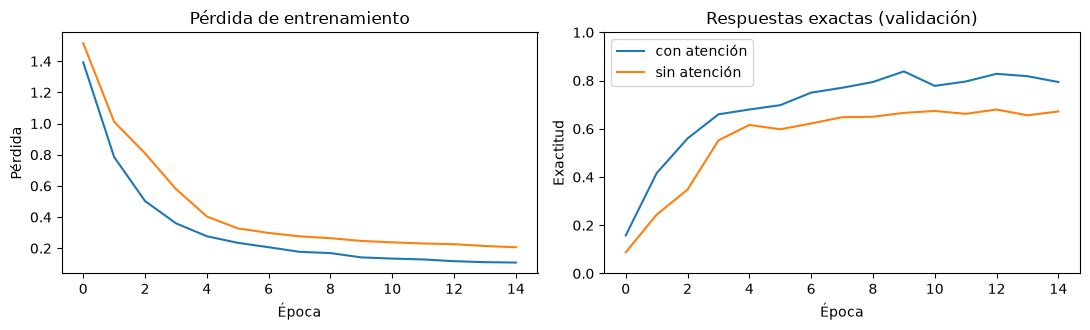

4821+3976 -> 8797
999+1 -> 1000
7305-2618 -> 4687
OK - calculadora entrenada. Exactitud con atención: 0.810, sin atención: 0.684


In [42]:
modelo_atencion, historia_atencion = entrenar(CONFIG_BASE, "base_con_atencion")
modelo_sin, historia_sin = entrenar({**CONFIG_BASE, "usar_atencion": False}, "base_sin_atencion")

fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4))
for historia, etiqueta in [(historia_atencion, "con atención"), (historia_sin, "sin atención")]:
    ejes[0].plot(historia["perdida"], label=etiqueta)
    ejes[1].plot(historia["exactitud_val"], label=etiqueta)
ejes[0].set(xlabel="Época", ylabel="Pérdida", title="Pérdida de entrenamiento")
ejes[1].set(xlabel="Época", ylabel="Exactitud", title="Respuestas exactas (validación)", ylim=(0, 1))
ejes[1].legend()
plt.tight_layout()
plt.show()

for problema in ["4821+3976", "999+1", "7305-2618"]:
    print(problema, "->", modelo_atencion.resolver([problema])[0])

exactitud_base = exactitud(modelo_atencion, validacion)
assert exactitud_base >= 0.60, "Revise los Bloques 2 y 3: la calculadora con atención no aprendió."
print(f"OK - calculadora entrenada. Exactitud con atención: {exactitud_base:.3f}, "
      f"sin atención: {exactitud(modelo_sin, validacion):.3f}")

---
## Bloque 5 - ¿Dónde ayuda la atención y qué está mirando? (15 puntos)

Dos herramientas, ya escritas:

1. **Exactitud por cifras.** Compara ambos modelos en problemas de 1 a 6 cifras. Las columnas 5 y 6 están
   **fuera** del rango de entrenamiento: nunca vio números tan largos.
2. **Mapa de atención.** Cada fila es un carácter que la red escribió; cada columna, un carácter del
   problema (en el orden en que la red lo leyó). Más oscuro = más peso.

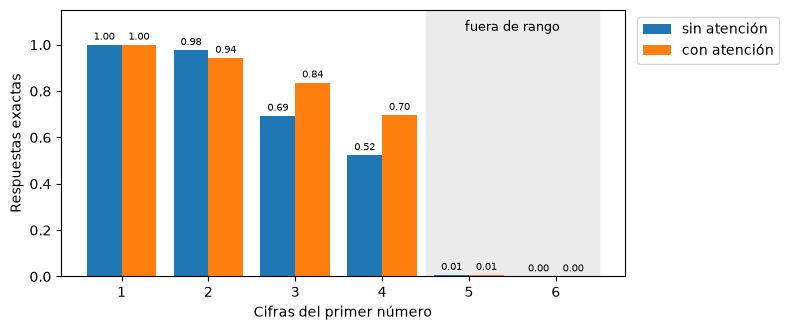

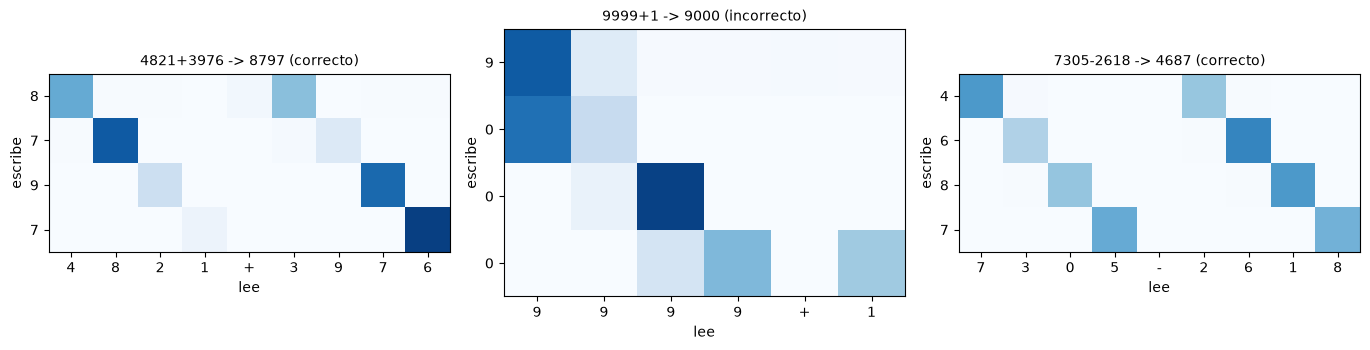

In [43]:
def exactitud_por_cifras(modelo, max_cifras=6, n=300):
    rng = random.Random(77)
    resultado = {}
    for cifras in range(1, max_cifras + 1):
        pares = [generar_problema(rng, max_cifras=cifras, min_cifras=cifras) for _ in range(n)]
        resultado[cifras] = exactitud(modelo, pares)
    return resultado


def graficar_por_cifras(modelos):
    plt.figure(figsize=(8, 3.4))
    ancho = 0.8 / len(modelos)
    for k, (etiqueta, modelo) in enumerate(modelos.items()):
        valores = exactitud_por_cifras(modelo)
        x = [c + (k - (len(modelos) - 1) / 2) * ancho for c in valores]
        barras = plt.bar(x, valores.values(), width=ancho, label=etiqueta)
        plt.bar_label(barras, fmt="%.2f", fontsize=7, padding=2)
    plt.axvspan(4.5, 6.5, color="0.92", zorder=0)
    plt.text(5.5, 1.06, "fuera de rango", ha="center", fontsize=9)
    plt.xlabel("Cifras del primer número")
    plt.ylabel("Respuestas exactas")
    plt.ylim(0, 1.15)
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.show()


def mapa_atencion(modelo, problemas):
    if not modelo.config["usar_atencion"]:
        print("Este modelo no usa atención: no tiene mapa que mostrar.")
        return
    fig, ejes = plt.subplots(1, len(problemas), figsize=(4.6 * len(problemas), 3.4))
    for eje, problema in zip(ejes, problemas):
        respuesta, pesos = modelo.resolver([problema], devolver_pesos=True)
        leido = preparar(problema, modelo.config["invertir_entrada"])
        escrito = preparar(respuesta[0], modelo.config["invertir_salida"])
        matriz = torch.stack([p[0] for p in pesos[:len(escrito)]])
        eje.imshow(matriz, cmap="Blues", vmin=0, vmax=1)
        eje.set_xticks(range(len(leido)), list(leido))
        eje.set_yticks(range(len(escrito)), list(escrito))
        eje.set_xlabel("lee" + (" (invertido)" if modelo.config["invertir_entrada"] else ""))
        eje.set_ylabel("escribe" + (" (invertido)" if modelo.config["invertir_salida"] else ""))
        correcto = "correcto" if respuesta[0] == respuesta_correcta(problema) else "incorrecto"
        eje.set_title(f"{problema} -> {respuesta[0]} ({correcto})", fontsize=10)
    plt.tight_layout()
    plt.show()


graficar_por_cifras({"sin atención": modelo_sin, "con atención": modelo_atencion})
mapa_atencion(modelo_atencion, ["4821+3976", "9999+1", "7305-2618"])

**Pregunta 5.1.** Según la gráfica, ¿en qué cantidad de cifras ayuda más la atención? ¿Por qué cree que
con 1 o 2 cifras la diferencia es pequeña? Relacione su respuesta con la pregunta 1 del Bloque 0.

La atención ayuda más con **3 y 4 cifras**: con 3 cifras sube de 0.69 (sin atención) a 0.84, y con 4 cifras de 0.52 a 0.70. Con 1 o 2 cifras la diferencia es pequeña (1.00 contra 1.00 y 0.98 contra 0.94; con 2 cifras incluso gana un poco el modelo sin atención), y con 5 cifras ambos quedan en ~0.01. Esto coincide con la pregunta 1 del Bloque 0: un problema corto como `7+5` cabe sin problema en un solo vector resumen, porque hay poca información que comprimir. A medida que el problema crece, ese único vector se vuelve un cuello de botella, como intentar recordar un número de teléfono largo de memoria. La atención permite volver a "mirar" los dígitos exactos en cada paso, y por eso su ventaja crece con la cantidad de cifras.

**Pregunta 5.2.** Describa el mapa de `4821+3976`. Cuando la red escribe cada dígito, ¿mira las cifras de
la misma columna en ambos números (unidades con unidades, decenas con decenas), o su atención está
dispersa? ¿Qué dificultad tiene la red al escribir **primero** el dígito de la izquierda?

El modelo base acierta `4821+3976 -> 8797`, y su atención está **bastante alineada por columnas, aunque no del todo**. Al escribir el "8" (millares) mira el "4" y el "3", la columna correcta. Al escribir el "7" mira sobre todo el "8" (centenas del primer número), al escribir el "9" mira sobre todo el "7" (decenas del segundo número) y al escribir el último "7" mira casi solo el "6" (unidades). Es decir, en la mayoría de los pasos mira **solo una** de las dos cifras de la columna, no las dos. La dificultad de escribir **primero** el dígito de la izquierda es que los millares dependen de **todos** los acarreos que vienen de la derecha, y la red tiene que adivinarlos antes de haber "hecho" las otras columnas. El caso `9999+1` lo muestra claramente: la red escribe primero un "9" (sin saber que viene un acarreo) y termina con `9000` en lugar de `10000`.


---
## Bloque 6 - Su calculadora para el torneo (10 puntos)

Ahora mejore la calculadora. Cambie **una o dos perillas** de `CONFIG` a partir de `CONFIG_BASE`, apoyado en
lo que investigó en el Bloque 0 y lo que vio en el Bloque 5. Algunas ideas, no una lista cerrada:

- invertir la entrada, la salida o ambas;
- más capacidad (`dim_oculta`), más ejemplos o más épocas;
- otra tasa de aprendizaje;
- modificar `generar_problema` para mostrar más casos difíciles (por ejemplo, acarreos en cadena), siempre
  con números de **máximo 4 cifras**.

**Reglas del torneo para este bloque.** No cambie la arquitectura: modifique solo `CONFIG` (y, si quiere,
el generador de datos, siempre con números de máximo 4 cifras). Máximo 750,000 parámetros. El tiempo de
entrenamiento es libre, pero tenga en cuenta su propio tiempo. La calculadora que entrene aquí es la que
compite en el torneo.

Antes de entrenar, complete la hipótesis:

**Hipótesis.** *"Creo que cambiar ______ mejorará ______ porque ______. Lo consideraré útil si ______."*

Creo que cambiar **`invertir_salida` a `True` y subir `epocas` de 15 a 40** mejorará **la exactitud en problemas de 3 y 4 cifras (y en los acarreos en cadena)** porque, al escribir la respuesta empezando por las unidades, la red sigue el mismo orden que la suma a mano: cuando llega a cada columna ya conoce el acarreo de la columna anterior (idea de dependencias cortas de Sutskever, sec. 3.3), y más épocas le dan tiempo de afinar esa regla. Lo consideraré útil si **la exactitud con 4 cifras sube de forma clara respecto al modelo base (de ~0.6 a más de 0.9) y el mapa de atención muestra una diagonal por columnas**.


[torneo_23643] cargado desde modelos_lab6/torneo_23643.pt - exactitud validación 0.975
Parámetros: 186767


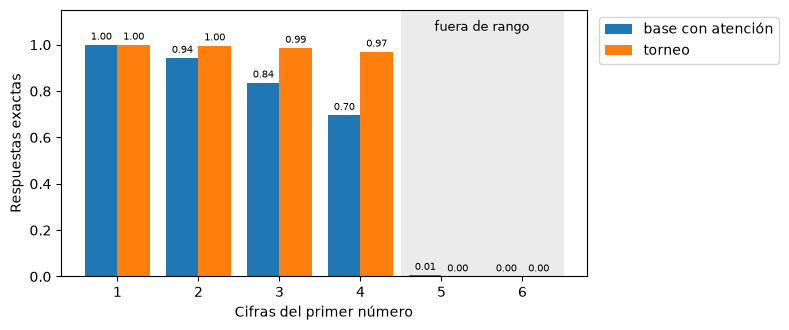

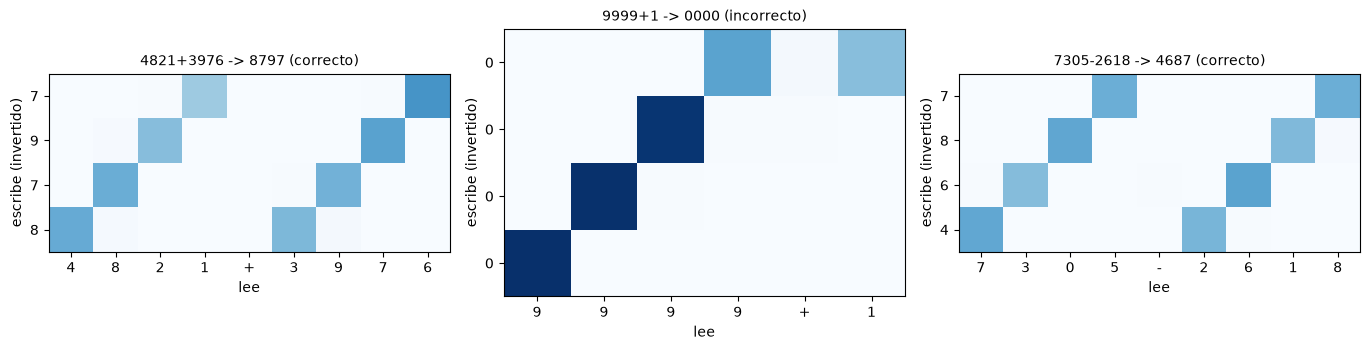

In [44]:
CONFIG_TORNEO = {
    **CONFIG_BASE,
    "invertir_salida": True,  # escribir la respuesta desde las unidades, como la suma a mano
    "epocas": 40,             # más tiempo para aprender la regla del acarreo
}

modelo_torneo, historia_torneo = entrenar(CONFIG_TORNEO, f"torneo_{CARNE}")
print("Parámetros:", contar_parametros(modelo_torneo))

graficar_por_cifras({"base con atención": modelo_atencion, "torneo": modelo_torneo})
mapa_atencion(modelo_torneo, ["4821+3976", "9999+1", "7305-2618"])

**Resultado.** ¿Se cumplió su hipótesis? Use los números de la gráfica y lo que cambió en el mapa de
atención. Mencione al menos una limitación de su comparación.

**Sí, se cumplió.** Con la misma arquitectura y el mismo número de parámetros (186,767), la calculadora del torneo pasó de 0.84 a **0.99** en problemas de 3 cifras y de 0.70 a **0.97** en problemas de 4 cifras, y la exactitud de validación subió de 0.810 a 0.975. El mapa de atención también cambió: en el modelo base cada dígito miraba casi siempre **una** cifra de la columna, y ahora forma **dos diagonales limpias**, es decir, mira **las dos** cifras de la misma columna. Al escribir las unidades mira el "1" de 4821 y el "6" de 3976; al escribir las decenas, el "2" y el "7"; y así sucesivamente. Es exactamente la suma por columnas.

**Limitaciones:**
1. Se cambiaron **dos** perillas a la vez, así que esta comparación sola no separa cuánto aportó cada una.
2. El entrenamiento no fue estable: en la época 30 la exactitud de validación iba en 0.992, en la época 35 cayó a 0.876 y terminó en 0.975. Más épocas no siempre significa mejor, y como se guarda el modelo de la última época, no el mejor, parte de la mejora se perdió.
3. Es una sola semilla: con otra semilla los números podrían variar.
4. Con 5 y 6 cifras la exactitud sigue en ~0, e incluso `9999+1` (cuya respuesta tiene 5 cifras) sale mal (`0000`): la mejora no generaliza fuera de lo que vio en el entrenamiento.


---
## Bloque 7 - Rompa su propia calculadora (10 puntos)

Un buen ingeniero conoce los límites de su modelo antes de que otros los encuentren. Busque **5 problemas
que su calculadora del torneo resuelva mal**. Pruebe, observe y ajuste: los acarreos largos, los ceros y
las restas con resultado pequeño son buenos lugares para empezar.

Cada problema debe respetar las reglas del entrenamiento: dos números enteros de **máximo 4 cifras**, sin
ceros a la izquierda, `+` o `-`, y resultado no negativo. Problemas de 5 cifras no cuentan: ahí ya sabemos
que falla.

Al lado de cada uno, escriba en un comentario **por qué** cree que falla.

In [45]:
TRAMPAS = [
    "1111+8889",  # por qué: acarreo en cadena por las 4 columnas (todas suman 10). Escribe "9900": lleva bien el acarreo dos columnas y luego lo "suelta". Las cadenas tan largas casi nunca salen en los datos al azar.
    "1000-995",   # por qué: resultado muy pequeño (5). Escribe "05": como escribe al revés, no sabe cuándo parar y agrega un cero a la izquierda. Casi nunca vio restas que "se comen" tres columnas.
    "1350-1349",  # por qué: resta de números casi iguales (resultado 1). Escribe "001": igual que la anterior, rellena con ceros porque no sabe cuántas cifras tendrá la respuesta.
    "1000-106",   # por qué: préstamo en cadena a través de varios ceros. Escribe "994" en vez de "894": acierta las unidades y las decenas, pero falla el préstamo en las centenas.
    "9999+1",     # por qué: el acarreo recorre las 4 columnas y crea una 5.ª cifra. Escribe "0000": hace bien cada columna, pero olvida el "1" final.
]


def es_trampa_valida(texto):
    for operacion in "+-":
        partes = texto.split(operacion)
        if len(partes) == 2 and all(p.isdigit() and len(p) <= MAX_CIFRAS for p in partes):
            a, b = partes
            if (len(a) > 1 and a[0] == "0") or (len(b) > 1 and b[0] == "0"):
                return False
            return operacion == "+" or int(a) >= int(b)
    return False


assert len(TRAMPAS) == 5 and all(es_trampa_valida(t) for t in TRAMPAS), "Escriba 5 problemas válidos."
assert len(set(TRAMPAS)) == 5, "Los 5 problemas deben ser distintos."
rotas = 0
for trampa, respuesta in zip(TRAMPAS, modelo_torneo.resolver(TRAMPAS)):
    falla = respuesta != respuesta_correcta(trampa)
    rotas += falla
    print(f"{trampa:>10} -> {respuesta:<7} {'FALLA' if falla else 'correcto: busque otro'}")
print(f"OK - {rotas} de 5 problemas rompen su calculadora")

 1111+8889 -> 9900    FALLA
  1000-995 -> 05      FALLA
 1350-1349 -> 001     FALLA
  1000-106 -> 994     FALLA
    9999+1 -> 0000    FALLA
OK - 5 de 5 problemas rompen su calculadora


**Reflexión final.** Escoja el problema que mejor expone la debilidad de su calculadora y mire su mapa de
atención en la celda siguiente. Con ese caso concreto, responda: ¿su red aprendió a **sumar** o aprendió a  
**imitar sumas**? ¿Qué evidencia de su propio modelo sostiene su respuesta?

El caso elegido es `1111+8889` (debería dar `10000`), y la calculadora escribe `9900`. El mapa de atención es lo más revelador: la red **mira perfectamente la columna correcta** en cada paso (unidades con unidades, decenas con decenas, una diagonal limpia). O sea, aprendió **dónde** mirar. Aun así, aunque cada columna suma 10, solo lleva bien el acarreo en las dos primeras; en las centenas y los millares escribe "9" como si no viniera ningún acarreo, y nunca escribe el "1" final. Una persona que sabe sumar aplica la regla "llevo uno" igual en todas las columnas; la red no.

La conclusión es que la red está **en medio**, pero más cerca de **imitar sumas**. Aprendió la estructura (alinear columnas, y por eso acierta ~97 % de los problemas de validación que nunca vio, algo imposible de memorizar según la pregunta 1.1). Pero el acarreo solo lo aplica bien en los casos que vio a menudo: con números al azar, que el acarreo recorra 3 o 4 columnas seguidas es muy raro, y justo ahí falla (`1111+8889`, `9999+1 -> 0000`, `1000-106`). Una calculadora real aplica la misma regla siempre; la red copia el patrón donde vio suficientes ejemplos.


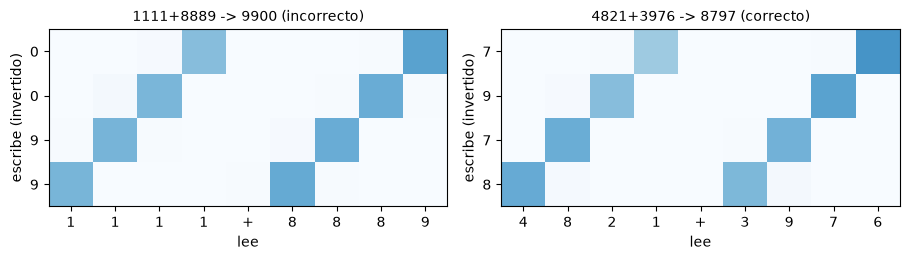

In [46]:
TRAMPA_ELEGIDA = TRAMPAS[0]  # cambie el índice si quiere analizar otro problema
mapa_atencion(modelo_torneo, [TRAMPA_ELEGIDA, "4821+3976"])

### Entrega

La celda siguiente **registra su calculadora** en el formulario del curso: envía su carné, la huella de su
modelo y los valores de verificación. Necesita conexión a internet. Si la ejecuta varias veces, cuenta el
último registro antes de la fecha límite.

Después, **suba a Canvas este notebook** ejecutado. Antes: reinicie el kernel, ejecute todo, confirme los
mensajes `OK` y guarde con las salidas visibles. Los modelos ya guardados en `modelos_lab6/` se cargan sin
volver a entrenar.

**No borre la carpeta `modelos_lab6/`:** la necesita el día del torneo. Si la pierde y vuelve a entrenar,
la huella cambia y su puntaje del torneo se reduce un 30 %.

In [47]:
VALORES_ENTREGA = {
    "pesos_b2": pesos_b2.round(decimals=4).tolist(),
    "contexto_b2": contexto_b2.round(decimals=4).tolist(),
    "logits_b3": logits_b3.round(decimals=4).tolist(),
    "estado_b3": estado_b3.round(decimals=4).tolist(),
}
registro = {
    "momento": "entrega",
    "carne": CARNE,
    "nombre": NOMBRE,
    "huella": huella(modelo_torneo),
    "parametros": contar_parametros(modelo_torneo),
    "config": modelo_torneo.config,
    "exactitud_validacion": round(exactitud(modelo_torneo, validacion), 4),
    "trampas": TRAMPAS,
    "valores": VALORES_ENTREGA,
}
marca = CARPETA_MODELOS / "registro_enviado.txt"
if marca.exists() and marca.read_text() == registro["huella"]:
    print("Esta calculadora ya estaba registrada: no se envía de nuevo.")
elif enviar_registro(registro):
    marca.write_text(registro["huella"])
print("Huella de su calculadora:", registro["huella"])
print("Exactitud de validación:", registro["exactitud_validacion"])

OK - registro enviado al formulario del curso
Huella de su calculadora: afb44b7d2312
Exactitud de validación: 0.9745


---
## Torneo de calculadoras neuronales - viernes 9 de octubre

**No ejecute nada aquí antes del torneo.** En clase, el profesor dirá en voz alta una **clave**. Abra este
notebook, ejecute todo (los modelos se cargan de `modelos_lab6/`, no se reentrenan), escriba la clave y
ejecute la última celda. Su calculadora resuelve los problemas secretos y **sus respuestas se registran
solas**. El profesor recalcula todos los puntajes a partir de esas respuestas.

| Nivel | Qué contiene | Puntos |
|:--|:--|--:|
| 1 · Calentamiento | 20 problemas de 1 a 3 cifras | 15 |
| 2 · Cuatro cifras | 20 problemas con ambos números de 4 cifras | 30 |
| 3 · Acarreos en cadena | 16 problemas donde el acarreo o el préstamo recorre varias columnas | 40 |
| 4 · Jefe final | 10 problemas con un número de **5 cifras**, nunca vistos | 15 |

**Su nota del Laboratorio 7** es su puntaje en el torneo dividido entre el mejor puntaje de la clase, por 100: **la mejor calculadora obtiene 100**, y nadie que envíe su calculadora baja de **60**. Vale 4 puntos de la nota final. Cuenta el **primer** envío con la clave correcta. La huella debe ser la misma que registró al
entregar: si no coincide (por ejemplo, porque volvió a entrenar), su puntaje se reduce un 30 %. Empate en
el podio: va primero la calculadora con menos parámetros. Los tres primeros lugares vuelven a ejecutar la
celda frente a la clase.

In [48]:
CLAVE = None  # el día del torneo: escriba aquí el número que diga el profesor, por ejemplo CLAVE = 1234


def cuatro_cifras(rng):
    a, b = rng.randint(1000, 9999), rng.randint(1000, 9999)
    operacion = rng.choice("+-")
    if operacion == "-" and a < b:
        a, b = b, a
    return f"{a}{operacion}{b}"


def acarreo_en_cadena(rng):
    """Sumas cuyas columnas suman 9 (el acarreo viaja de punta a punta) o restas desde un número redondo."""
    cifras = rng.randint(3, 4)
    if rng.random() < 0.5:
        a = [rng.randint(1 if i == 0 else 0, 9) for i in range(cifras)]
        b = [9 - x for x in a]
        b[-1] = min(9, b[-1] + 1)
        return f"{''.join(map(str, a))}+{''.join(map(str, b)).lstrip('0') or '0'}"
    a = rng.randint(1, 9) * 10 ** (cifras - 1)
    return f"{a}-{rng.randint(1, 99)}"


def cinco_cifras(rng):
    return f"{rng.randint(10000, 99999)}{rng.choice('+-')}{rng.randint(10, 9999)}"


def generar_torneo(clave):
    rng = random.Random(f"torneo-{clave}")
    return {
        "1 · Calentamiento": (15, [generar_problema(rng, max_cifras=3)[0] for _ in range(20)]),
        "2 · Cuatro cifras": (30, [cuatro_cifras(rng) for _ in range(20)]),
        "3 · Acarreos en cadena": (40, [acarreo_en_cadena(rng) for _ in range(16)]),
        "4 · Jefe final": (15, [cinco_cifras(rng) for _ in range(10)]),
    }


def calificar_torneo(niveles, respuestas):
    puntaje = {}
    for nivel, (puntos, problemas) in niveles.items():
        aciertos = sum(r == respuesta_correcta(p) for r, p in zip(respuestas[nivel], problemas))
        puntaje[nivel] = puntos * aciertos / len(problemas)
    return puntaje


if CLAVE is None:
    print("Torneo: espere la clave del viernes 9 de octubre.")
else:
    niveles = generar_torneo(CLAVE)
    respuestas_torneo = {nivel: modelo_torneo.resolver(problemas)
                         for nivel, (_, problemas) in niveles.items()}
    puntaje = calificar_torneo(niveles, respuestas_torneo)
    for nivel, puntos in puntaje.items():
        print(f"{nivel:24s} {puntos:5.1f} / {niveles[nivel][0]}")
    print(f"{'TOTAL':24s} {sum(puntaje.values()):5.1f} / 100")
    enviar_registro({
        "momento": "torneo",
        "carne": CARNE,
        "nombre": NOMBRE,
        "clave": CLAVE,
        "huella": huella(modelo_torneo),
        "parametros": contar_parametros(modelo_torneo),
        "respuestas": respuestas_torneo,
    })

Torneo: espere la clave del viernes 9 de octubre.
